### Descripción
Después de tu análisis exploratorio inicial, el equipo de marketing quedó impresionado y ahora quiere que crees visualizaciones más específicas y pulidas para una presentación a los directivos. Tu tarea es generar gráficos que no solo muestren los datos, sino que también cuenten una historia de manera clara y estéticamente agradable.
Objetivos de Evaluación:
* Aplicar técnicas de análisis visual de los datos utilizando la librería Seaborn para la representación gráfi ca de la información.
* Aplicar personalizaciones a los gráficos de datos utilizando la librería Matplotlib para la resolución de un problema dado.
Instrucciones:
* Carga el DataFrame de videojuegos (videojuegos.csv) y completa las siguientes tareas de visualización.

Requerimientos
Parte 1: Análisis Visual con Seaborn
Usa la librería Seaborn para crear gráficos que revelen relaciones complejas en los datos.
1. Gráfico de Pares (pairplot): (2 Puntos)
* Crea un pairplot para visualizar la relación entre todas las variables numéricas (Ventas_NA, Ventas_EU, Ventas_JP, Critica_Puntaje).
* Diferencia los puntos por Plataforma usando el parámetro hue. Esto te permitirá ver si las relaciones entre ventas y puntajes varían según la plataforma.
2. Gráfico de Violín (violinplot): (2 Puntos)
* Genera un violinplot que muestre la distribución de Critica_Puntaje para cada Plataforma. Esto te ayudará a comparar tanto la densidad de los puntajes como sus rangos entre las diferentes plataformas.
3. Mapa de Calor (heatmap): (2 Puntos)
* Calcula la matriz de correlación de las variables numéricas.
* Crea un heatmap para visualizar esta matriz de correlación. Asegúrate de mostrar los valores de correlación en el mapa para que sea fácil de interpretar.

Parte 2: Personalización de Gráficos con Matplotlib
Crea un gráfico informativo y personalízalo para que sea claro, legible y profesional.
4. Preparación de Datos: (1.5 Puntos)
* Calcula el total de ventas globales (Ventas_Globales) para cada juego.
* Agrupa los datos por Genero y calcula la media de Ventas_Globales para cada uno.
* Creación y Personalización del Gráfico de Barras:
* Crea un gráfico de barras que muestre las ventas globales promedio por género.
5. Aplica las siguientes personalizaciones usando Matplotlib: (1.5 Puntos)
* Añade un título descriptivo como "Promedio de Ventas Globales por Género de Videojuego".
* Establece etiquetas claras para los ejes X e Y.
* Cambia el color de las barras a un azul acero (steelblue).
6. Añade un borde negro a las barras. (1 Punto)
* Fija los límites del eje Y para que comience en 0 y termine un poco por encima del valor máximo para dar espacio visual.
* Añade anotaciones de texto sobre cada barra para mostrar el valor exacto del promedio de ventas.
* Guarda el gráfico fi nal en un archivo llamado ventas_por_genero_personalizado.png.

In [ ]:
#&&&&&&&&&&&&&&&    Importar librería    &&&&&&&&&&&&&&&
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#&&&&&&&&&&&&&&&    Cargar datos     &&&&&&&&&&&&&&&
df = pd.read_csv("06. videojuegos.csv")
print(df.columns)
df.head()

Index(['Nombre', 'Plataforma', 'Anio_Lanzamiento', 'Genero', 'Ventas_NA',
       'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje'],
      dtype='object')


In [5]:
#&&&&&&&&&&&&&&&    exploración de datos      &&&&&&&&&&&&&&&
df.info()
print(f'\nFilas: {df.shape[0]} | Columnas: {list(df.columns)}')
print("\nTipos de datos:")
print(df.dtypes)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nombre            100 non-null    object 
 1   Plataforma        100 non-null    object 
 2   Anio_Lanzamiento  100 non-null    int64  
 3   Genero            100 non-null    object 
 4   Ventas_NA         100 non-null    float64
 5   Ventas_EU         100 non-null    float64
 6   Ventas_JP         100 non-null    float64
 7   Critica_Puntaje   90 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 6.4+ KB

Filas: 100 | Columnas: ['Nombre', 'Plataforma', 'Anio_Lanzamiento', 'Genero', 'Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje']

Tipos de datos:
Nombre               object
Plataforma           object
Anio_Lanzamiento      int64
Genero               object
Ventas_NA           float64
Ventas_EU           float64
Ventas_JP           float64
Critica_Puntaje

,Anio_Lanzamiento,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
count,100.000000,100.000000,100.000000,100.000000,90.000000
mean,2016.490000,8.108120,4.795395,2.645642,68.700000
std,3.783257,4.359312,2.901882,1.568193,17.873117
min,2010.000000,0.175418,0.242496,0.054188,40.000000
25%,2013.000000,4.484096,1.992912,1.456681,52.000000
50%,2017.000000,8.706121,5.024023,2.758458,68.500000
75%,2020.000000,11.946344,7.093285,3.984421,85.750000
max,2022.000000,14.851802,9.906001,4.964824,99.000000


aparentemente no se ven outliers de lo quer se obtuvo con el comando describe

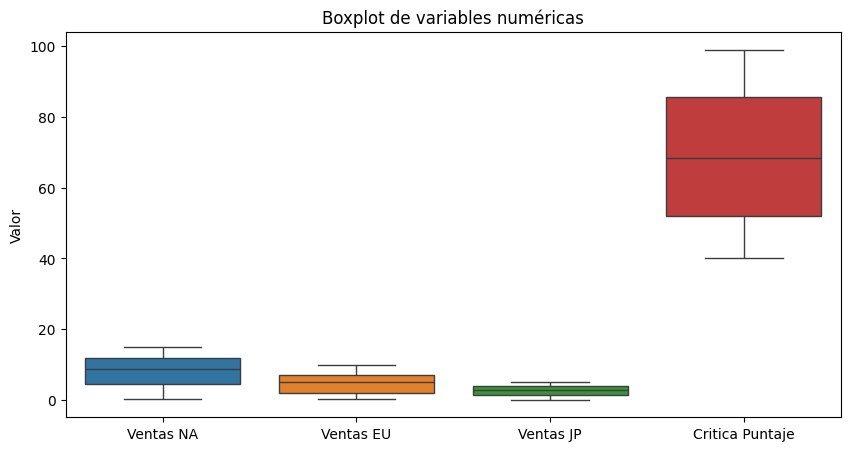

In [19]:
columnas = ["Ventas_NA", "Ventas_EU", "Ventas_JP", "Critica_Puntaje"]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columnas])
plt.title("Boxplot de variables numéricas")
plt.xticks(ticks=range(len(columnas)), labels=[Etiquetas[c] for c in columnas])
plt.ylabel("Valor")
plt.show()

No hay outliers por lotanto no hay que eliminar filas ni aplicar winsorización/capping

In [6]:
# Verificación de valores nulos y duplicados
print("Valores nulos por columna:\n", df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
 Nombre               0
Plataforma           0
Anio_Lanzamiento     0
Genero               0
Ventas_NA            0
Ventas_EU            0
Ventas_JP            0
Critica_Puntaje     10
dtype: int64

Filas duplicadas: 0


Hay 10 valores nulos, en la tarea no se especifica que hacer con ellos, igual de todas forma en este caso cada función maneja por su cuenta esto valores nulos:
En el caso de sns.pairplot y sns.violinplot, descartan las filas con NaN en la variable que están graficando.
En el caso de df.corr(): usa "pairwise deletion" para cada par de columnas, excluye solo las filas donde falta alguna de esas dos, no toda la fila. Por eso cada grafico funciona sin error.

In [14]:
# Etiquetas legibles (sin modificar el DataFrame original)
Etiquetas = {
    "Ventas_NA": "Ventas NA",
    "Ventas_EU": "Ventas EU",
    "Ventas_JP": "Ventas JP",
    "Critica_Puntaje": "Critica Puntaje",
    "Ventas_Globales": "Ventas Globales",
    "Genero": "Género",
    "Plataforma": "Plataforma",
}

## Parte 1: Análisis Visual con Seaborn

### 1. Gráfico de Pares (pairplot): (2 Puntos)

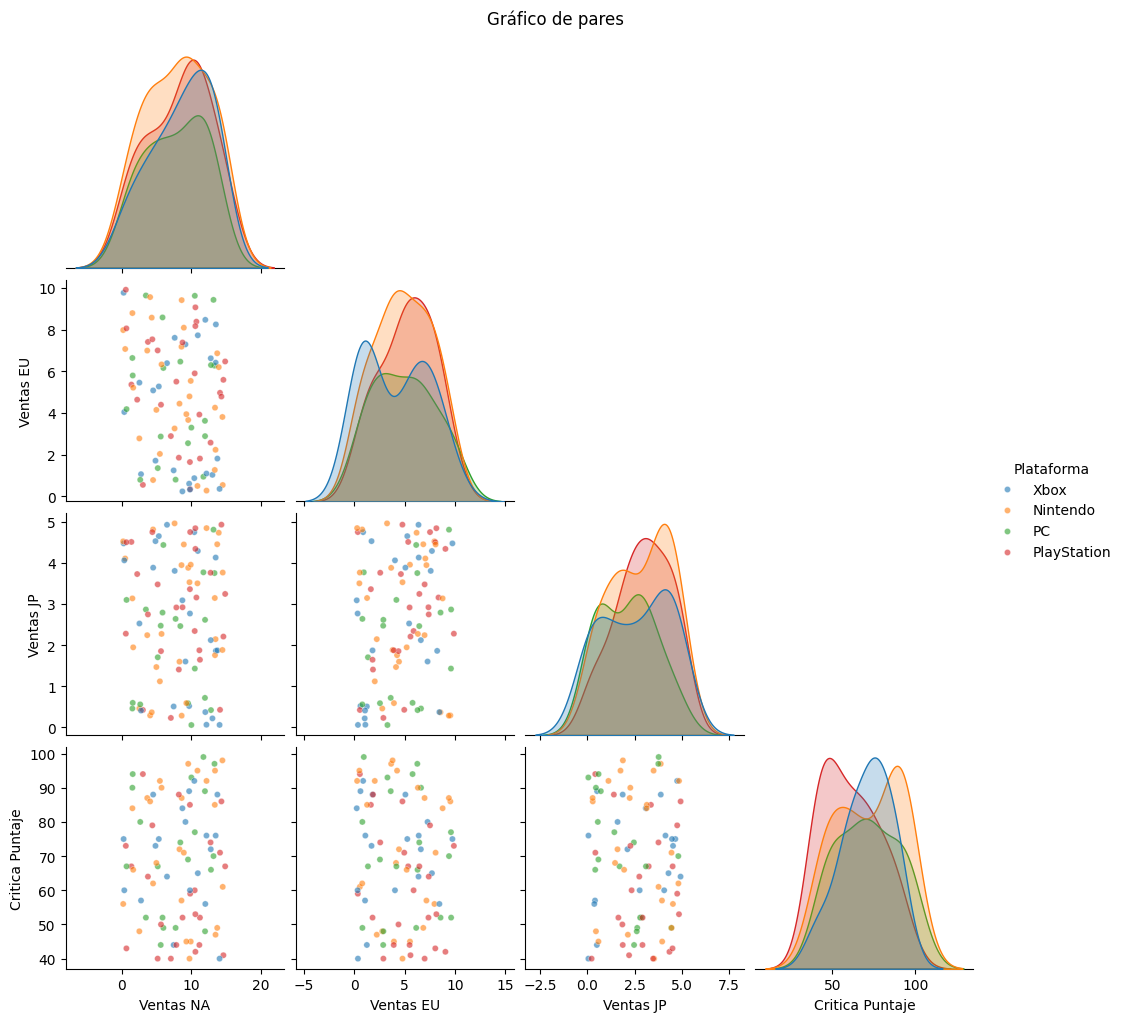

In [ ]:
#● Crea un pairplot para visualizar la relación entre todas las variables numéricas (Ventas_NA, Ventas_EU, Ventas_JP, Critica_Puntaje).
#● Diferencia los puntos por Plataforma usando el parámetro hue. 
# Esto te permitirá ver si las relaciones entre ventas y puntajes varían según la plataforma.

g = sns.pairplot(
    data=df,vars=["Ventas_NA", "Ventas_EU", "Ventas_JP", "Critica_Puntaje"], hue="Plataforma",
    corner=True,                    # evita duplicar los gráficos espejo (arriba/abajo de la diagonal)
    plot_kws=dict(alpha=0.6, s=20)  # transparencia para ver mejor la densidad de puntos superpuestos
)

for ax in g.axes.flat:
    if ax is not None:
        ax.set_xlabel(Etiquetas.get(ax.get_xlabel(), ax.get_xlabel()))
        ax.set_ylabel(Etiquetas.get(ax.get_ylabel(), ax.get_ylabel()))

g.fig.suptitle("Gráfico de pares", y=1.02)
plt.show()
plt.show()

Interpretación del pairplot:
 Se observa que las variables presentan relaciones débiles entre sí (se ven puntos disperso que como nube y no se ve una línea de estos). No se observan patrones lineales claros entre las ventas de las distintas regiones ni entre las ventas y el puntaje de la crítica(no se aprecia una tendencia ascendente o descendente). 
 Además, se puede decir que no existe una plataforma que concentre exclusivamente los juegos con mayores ventas o mejores críticas (las plataformas muestran una distribución similar, sin agrupamientos claramente diferenciados)

### 2. Gráfico de Violín (violinplot): (2 Puntos)

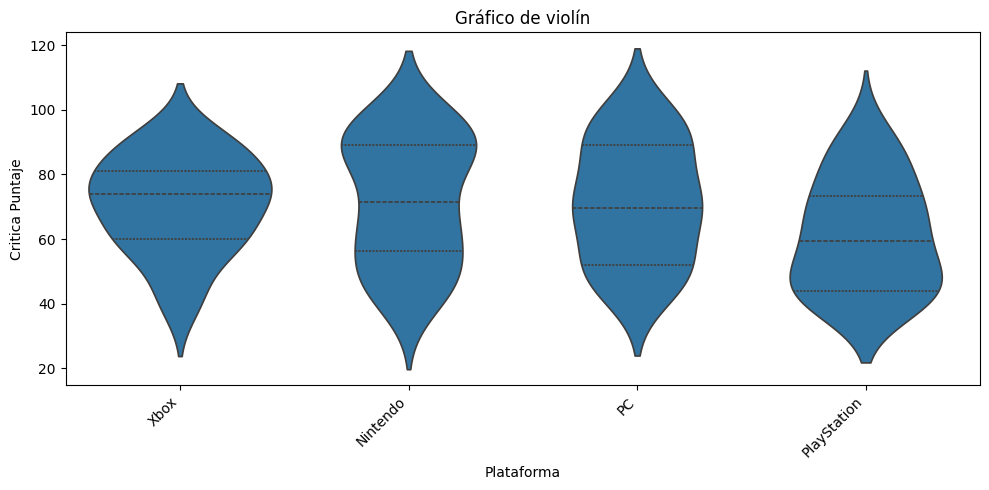

In [ ]:
# ● Genera un violinplot que muestre la distribución de Critica_Puntaje para cada Plataforma. 
# Esto te ayudará a comparar tanto la densidad de los puntajes como sus rangos entre las diferentes plataformas.
plt.figure(figsize=(10, 5))

sns.violinplot(data=df, x="Plataforma", y="Critica_Puntaje", inner="quartile") #mostar quiartiles
plt.title("Gráfico de violín")
plt.xlabel(Etiquetas["Plataforma"])
plt.ylabel(Etiquetas["Critica_Puntaje"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Interpretacion del violinplot:
 indica que la distribución de los puntajes de crítica es semejante entre las distintas plataformas. La mayor concentración de juegos se encuentra en valores intermedios de crítica y no se observan diferencias importantes en la dispersión de los puntajes entre plataformas.

### 3. Mapa de Calor (heatmap): (2 Puntos)

                 Ventas_NA  Ventas_EU  Ventas_JP  Critica_Puntaje
Ventas_NA         1.000000  -0.204332  -0.023772         0.040401
Ventas_EU        -0.204332   1.000000   0.180201        -0.121058
Ventas_JP        -0.023772   0.180201   1.000000        -0.071047
Critica_Puntaje   0.040401  -0.121058  -0.071047         1.000000


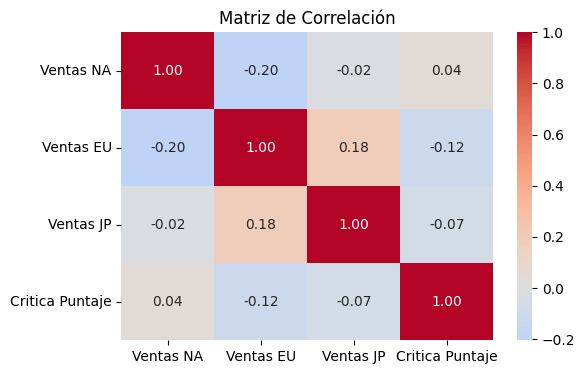

In [16]:
# ● Calcula la matriz de correlación de las variables numéricas.
# ● Crea un heatmap para visualizar esta matriz de correlación. 
# Asegúrate de mostrar los valores de correlación en el mapa para que sea fácil de interpretar.
correlacion = df[["Ventas_NA", "Ventas_EU", "Ventas_JP", "Critica_Puntaje"]].corr()

print(correlacion)

labels_limpios = [Etiquetas.get(c, c) for c in correlacion.columns]

plt.figure(figsize=(6, 4))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", center=0,
            xticklabels=labels_limpios, yticklabels=labels_limpios) #sacar el _ en nombre variable
plt.title("Matriz de Correlación")
plt.show()

Interpretación del Heatmap:
se puede ver que la matriz es de color azul eso significa que hay baja relacion entre las variables, la diagonal es de color rojo porque es la relacion de cada variable con si misma.

## Parte 2: Personalización de Gráficos con Matplotlib
Crea un gráfico informativo y personalízalo para que sea claro, legible y profesional.

### 4. Preparación de Datos: (1.5 Puntos) y 5. Aplica las siguientes personalizaciones usando Matplotlib: (1.5 Puntos)

       Genero  Ventas_Globales
0      Acción        15.884657
1    Aventura        12.376321
2    Deportes        14.800334
3  Estrategia        16.835730
4         RPG        15.784117


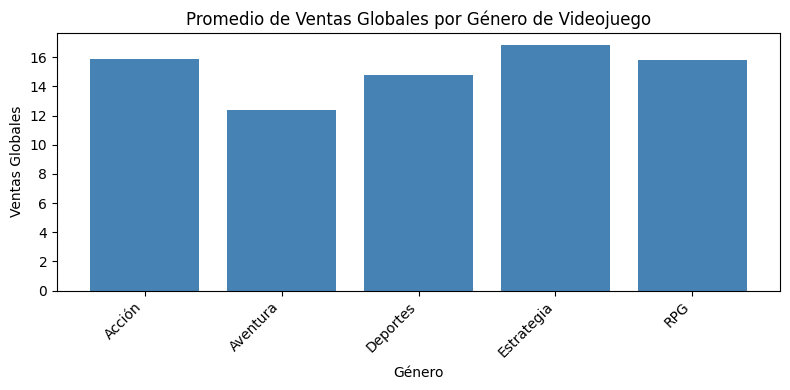

In [17]:
# ● Calcula el total de ventas globales (Ventas_Globales) para cada juego.
df["Ventas_Globales"] = (df["Ventas_NA"] + df["Ventas_EU"] + df["Ventas_JP"])
# ● Agrupa los datos por Genero y calcula la media de Ventas_Globales para cada uno.
ventas_genero = (df.groupby("Genero")["Ventas_Globales"].mean())
# ● Creación y Personalización del Gráfico de Barras:
ventas_genero = ventas_genero.reset_index()
print(ventas_genero)
# ● Crea un gráfico de barras que muestre las ventas globales promedio por género.
plt.figure(figsize=(8,4))
# ● Cambia el color de las barras a un azul acero (steelblue).
plt.bar(ventas_genero["Genero"],ventas_genero["Ventas_Globales"], color="steelblue")
# ● Añade un título descriptivo como "Promedio de Ventas Globales por Género de Videojuego".
plt.title("Promedio de Ventas Globales por Género de Videojuego")
# ● Establece etiquetas claras para los ejes X e Y.
plt.xlabel(Etiquetas["Genero"])
plt.ylabel(Etiquetas["Ventas_Globales"])
plt.xticks(rotation=45, ha="right")
# ● Crea un gráfico de barras que muestre las ventas globales promedio por género.
plt.tight_layout()
plt.show()


### 6. Añade un borde negro a las barras. (1 Punto)

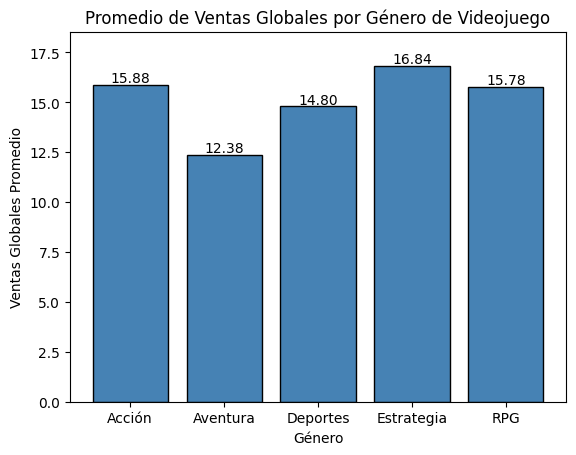

In [18]:
# ● Fija los límites del eje Y para que comience en 0 y termine un poco por encima del valor máximo para dar espacio visual.
maximo = ventas_genero["Ventas_Globales"].max()
#plt.ylim(0, maximo + 2)
plt.ylim(0, maximo*1.10)
# ● Añade anotaciones de texto sobre cada barra para mostrar el valor exacto del promedio de ventas.
plt.title("Promedio de Ventas Globales por Género de Videojuego")
plt.xlabel("Género")
plt.ylabel("Ventas Globales Promedio")
barras = plt.bar(
    ventas_genero["Genero"],
    ventas_genero["Ventas_Globales"],
    color="steelblue",
    edgecolor="black")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.1,
        f"{altura:.2f}",
        ha="center")
# ● Guarda el gráfico final en un archivo llamado ventas_por_genero_personalizado.png.
plt.savefig(
    "ventas_por_genero_personalizado.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

interpretación del grafico de barras:
con este tipo de grafico es facil ver que videojuegos presentan las mayores ventas globales promedio y cuáles poseen un menor desempeño. 